In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
#import os
#os.environ["OMP_NUM_THREADS"] = "8"
N_QUBITS = 8
df_data = pd.read_csv('features_cleaned.csv')

X = df_data.drop(columns=['class', 'image_name'])

y = df_data['class']

pca = PCA(n_components=N_QUBITS)
X_pca= pca.fit_transform(X)  

print(X.shape)
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X_final = X_pca.copy()


# 2. Normaliza para [0, π] 
# scaler = MinMaxScaler()
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_final)


classes_existentes = sorted(y.unique()) 
n_classes = len(classes_existentes)



X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y , test_size=0.3, random_state=42, stratify=y
)


print("X_train shape:", X_train.shape)  
print("X_test shape: ", X_test.shape)   
print("Primeira amostra:", X_train[0])

(43699, 42)
X_train shape: (30589, 8)
X_test shape:  (13110, 8)
Primeira amostra: [0.25816951 1.6246649  1.96395557 0.8797291  0.54947036 1.34627982
 2.39294116 2.48912102]


In [2]:
print(pca.explained_variance_ratio_.cumsum())

[0.71014935 0.87720504 0.92484102 0.9514133  0.97041651 0.97762079
 0.98402992 0.98838624]


Usando 8 qubits


C:\Users\SCIS\AppData\Local\Temp\ipykernel_30812\2760526398.py:24: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(num_features, reps=1, insert_barriers=True)
C:\Users\SCIS\AppData\Local\Temp\ipykernel_30812\2760526398.py:27: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz =  RealAmplitudes(num_features, reps=1)


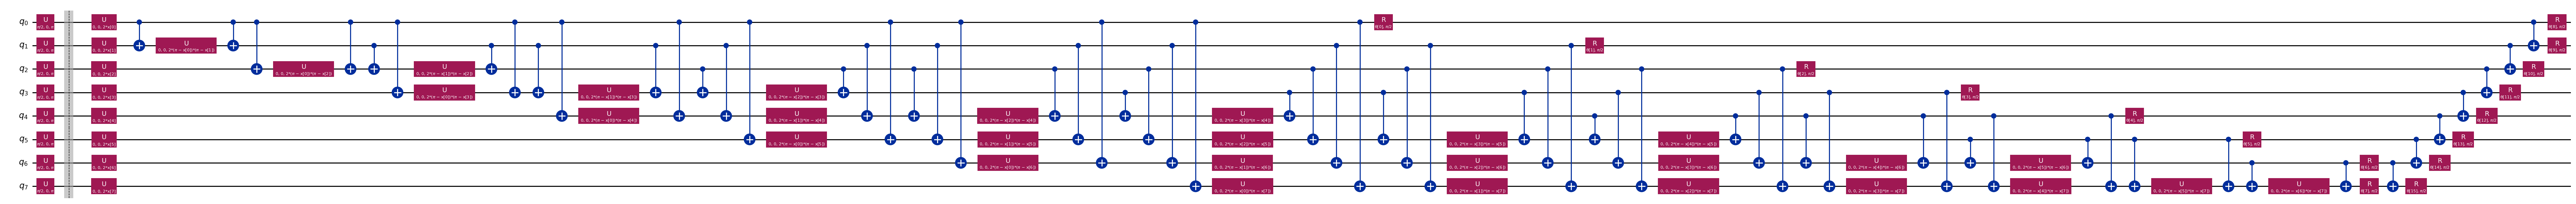

In [3]:
from qiskit.circuit.library import RealAmplitudes
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from sklearn.model_selection import train_test_split


num_features = X_pca.shape[1]        
print(f"Usando {num_features} qubits")


feature_map = ZZFeatureMap(num_features, reps=1, insert_barriers=True)


ansatz =  RealAmplitudes(num_features, reps=1) 


qc = QuantumCircuit(num_features)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)


qc.decompose(reps=2).draw("mpl", fold=-1)

In [4]:
from qiskit.quantum_info import Pauli
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.primitives import StatevectorEstimator

#FOR 8 QUBITS
observables = [
    Pauli("ZIIIIIII"),
    Pauli("IZIIIIII"),
    Pauli("IIZIIIII"),
    Pauli("IIIZIIII"),
    Pauli("IIIIZIII"),
    Pauli("IIIIIZII"),
    Pauli("IIIIIIZI"),
    Pauli("IIIIIIIZ"),
]
# observables = [
#     Pauli("ZIIIII"),
#     Pauli("IZIIII"),
#     Pauli("IIZIII"),
#     Pauli("IIIZII"),
#     Pauli("IIIIZI"),
#     Pauli("IIIIIZ"),
# ]
estimator = StatevectorEstimator()

qnn = EstimatorQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
    observables=observables
)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


In [5]:
from qiskit_machine_learning.connectors import TorchConnector
import torch
import torch.nn as nn


if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

quantum_layer = TorchConnector(qnn)


Using device: cpu


In [6]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.quantum = quantum_layer
        self.classical = nn.Sequential(
            nn.Linear(N_QUBITS, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 21)
        )
        
    def forward(self, x):
        x = self.quantum(x)
        x = self.classical(x)
        return x

In [7]:
from sklearn.utils import resample

X_train_small, y_train_small = resample(
    X_train, y_train,
    n_samples=10000,
    stratify=y_train,  # keeps class balance
    random_state=42
)

In [8]:
from sklearn.utils.class_weight import compute_class_weight

X_tensor = torch.tensor(X_train_small, dtype=torch.float32)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_train_small) #necessário para não dar erro de string


y_tensor = torch.tensor(y_encoded, dtype=torch.long)

from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
)

model = HybridModel()

# Class weights to handle imbalanced classes
weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32))

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

In [9]:
epochs = 30
torch.set_num_threads(8)

for epoch in range(epochs):
    total_loss = 0
    loaders = 0
    
    for xb, yb in loader:

        print(f"Inicio iteração para {len(loader)} loaders. Restam {(len(loader) - loaders)}")
        optimizer.zero_grad()
        
        outputs = model(xb)
        loss = criterion(outputs, yb)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        print(f"Loss até aqui: {total_loss/len(loader)}")

        loaders = loaders + 1 
    
    avg_loss = total_loss / len(loader)
    scheduler.step(avg_loss)
    
    print(f"Fim de Epoch {epoch+1}, Loss: {avg_loss}, LR: {optimizer.param_groups[0]['lr']}")

Inicio iteração para 79 loaders. Restam 79
Loss até aqui: 0.03883163536651225
Inicio iteração para 79 loaders. Restam 78
Loss até aqui: 0.07766025277632702
Inicio iteração para 79 loaders. Restam 77
Loss até aqui: 0.11602474767950517
Inicio iteração para 79 loaders. Restam 76
Loss até aqui: 0.15455965754352038
Inicio iteração para 79 loaders. Restam 75
Loss até aqui: 0.1929906440686576
Inicio iteração para 79 loaders. Restam 74
Loss até aqui: 0.23092346855356724
Inicio iteração para 79 loaders. Restam 73
Loss até aqui: 0.2686768543871143
Inicio iteração para 79 loaders. Restam 72
Loss até aqui: 0.30650265005570426
Inicio iteração para 79 loaders. Restam 71
Loss até aqui: 0.34442228305188916
Inicio iteração para 79 loaders. Restam 70
Loss até aqui: 0.3823547031306013
Inicio iteração para 79 loaders. Restam 69
Loss até aqui: 0.4200007885317259
Inicio iteração para 79 loaders. Restam 68
Loss até aqui: 0.45777897895136965
Inicio iteração para 79 loaders. Restam 67
Loss até aqui: 0.49517298

In [10]:
from sklearn.metrics import classification_report

model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    outputs = model(X_test_tensor)
    _, y_pred = torch.max(outputs, dim=1)
    y_pred = y_pred.numpy()

y_test_encoded = le.transform(y_test)

# Full per-class report
print(classification_report(
    y_test_encoded, 
    y_pred, 
    target_names=le.classes_  # shows original class names instead of numbers
))

              precision    recall  f1-score   support

           A       0.89      0.92      0.90       637
           B       0.93      0.94      0.93       634
           C       0.61      0.50      0.55       632
           D       0.84      0.71      0.77       627
           E       0.70      0.81      0.75       639
           F       0.68      0.51      0.59       597
           G       0.69      0.74      0.71       627
           I       0.89      0.86      0.87       627
           L       0.62      0.79      0.70       627
           M       0.75      0.79      0.77       627
           N       0.83      0.79      0.81       624
           O       0.79      0.71      0.75       581
           P       0.66      0.63      0.64       626
           Q       0.74      0.88      0.81       627
           R       0.60      0.63      0.61       627
           S       0.83      0.77      0.80       627
           T       0.70      0.74      0.72       616
           U       0.58    